# Detecção de Fraudes em Cartões de Crédito

O objetivo do projeto é desenvolver um modelo de Machine Learning capaz de reconhecer transações fraudulentas para que os clientes não sejam cobrados por itens que não compraram.

O melhor modelo será o que apresentar o menor erro nos falsos negativos, com um desempenho competitivo, explico.

Temos 2 erros neste problema. O erro do Tipo 1, os falsos positivos, o modelo indica que houve fraude, porém, na realidade não houve. Este erro traz um constrangimento ao cliente por bloquear uma transação genuína. O erro do Tipo 2, os falsos negativos, o modelo indica que não houve fraude, porém, houve. Neste caso, também será gerado um constrangimento ao cliente, pois irá aparecer uma compra na sua fatura que nunca realizou somado a um problema para a empresa, que terá de abrir um processo burocrático investigativo que pode resultar até mesmo em perda de recurso para a empresa.

Serão analisadas as métricas recall, precision, pontuação F1 com destaque para curva ROC como indica o livro https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_4_PerformanceMetrics/Introduction.html


## Importando os Dados

Os dados que usaremos neste projeto foram disponibilizados por algumas empresas europeias de cartão de crédito. [Na página original dos dados](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) podemos encontrar algumas informações importantes. 

O *dataset* representa as operações financeiras que aconteceram no período de dois dias, onde foram classificadas 492 fraudes em meio a quase 290 mil transações, o que representa apenas 0,17% do total, sendo um conjunto de dados extremamente desbalanceado.

A variável `Time` contém os segundos decorridos entre cada transação e a primeira transação no conjunto de dados.<br>
A variável `Amount` contém o valor da transação.<br>
As variáveis `[V1, V2, V3... V28]` são o resultado de uma transformação PCA, que permite a redução da dimensionalidade enquanto mantém o maior número possível de informações e foram descaracterizadas (por problemas ligados à privacidade e segurança).

In [2]:
# importa os pacotes necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikitplot as skplt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, roc_curve, auc

# configura o estilo dos gráficos com o Seaborn
sns.set_style('dark')

# suprimi alguns warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [4]:
# versões dos pacotes
%reload_ext watermark
%watermark --iversions

seaborn   : 0.12.2
matplotlib: 3.8.3
scikitplot: 0.3.7
pandas    : 2.2.1
numpy     : 1.26.4



In [5]:
# importa os dados para um dataframe
df = pd.read_csv('creditcard.csv')

# dimensões do conjunto original
print("Dimensões do Conjunto Original: ", df.shape)

# criando o conjunto de teste
test = df.sample(frac=0.15, random_state=0)

# drop das linhas de teste
df = df.drop(test.index)

# verificando o conjunto
print("Dimensões do Conjunto de Treino: ", df.shape)
print("Dimensões do Conjunto de Teste: ", test.shape)

Dimensões do Conjunto Original:  (284807, 31)
Dimensões do Conjunto de Treino:  (242086, 31)
Dimensões do Conjunto de Teste:  (42721, 31)


## Análise Exploratória

In [6]:
# verifica as primeiras entradas
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
# verifica o resumo estatístico
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,...,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000,242086.000000
mean,94857.597379,0.001456,-0.000800,-0.001004,0.000647,-0.000986,-0.001196,-0.000033,-0.000416,-0.000725,...,-0.000015,0.000606,-0.000482,0.000199,0.000048,-0.000269,-0.000727,0.000065,88.612429,0.001727
std,47490.660832,1.956513,1.654883,1.514580,1.417228,1.366284,1.326879,1.223095,1.199718,1.099350,...,0.734189,0.726284,0.629651,0.605150,0.521574,0.482084,0.401490,0.327734,247.655020,0.041517
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.822684,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,54234.000000,-0.920406,-0.598659,-0.893374,-0.848236,-0.693615,-0.769025,-0.553805,-0.208857,-0.645058,...,-0.228492,-0.542962,-0.161941,-0.354494,-0.316853,-0.327387,-0.070744,-0.052903,5.662500,0.000000
50%,84747.000000,0.019230,0.064567,0.177607,-0.018959,-0.054544,-0.274310,0.040344,0.022160,-0.051370,...,-0.028987,0.007162,-0.011175,0.040764,0.017175,-0.052337,0.001131,0.011209,22.000000,0.000000
75%,139362.000000,1.316034,0.803174,1.026561,0.743691,0.611455,0.397688,0.570104,0.327186,0.597195,...,0.187064,0.529814,0.147358,0.439320,0.350795,0.241214,0.090776,0.078234,77.580000,0.000000
max,172792.000000,2.451888,22.057729,9.382558,16.875344,34.801666,23.917837,44.054461,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


Verificando o resumo estatístico, podemos confirmar que as variáveis relativas aos componentes principais (transformação PCA) não têm nenhuma discrepância aparente, bem como a coluna `Time`.

Em relação à variável `Amount`, nota-se que o valor médio de transações (considerando ambas as classes) é 88.61, mediana igual a 22.00 e desvio padrão de 247.65. Atingindo o valor máximo de 19656.53, a maioria das transações financeiras é composta em sua maioria por quantias menores.

In [8]:
# verifica se há valores duplicados
df.duplicated().sum()

801

Foram encontrados entradas com valores duplicados, sendo necessário a remoção destas.

In [9]:
# copia para manter o dataset original
df1 = df.copy()

# remoção dos valores duplicados
df1 = df1.drop_duplicates()

# verifica se há valores duplicados
df1.duplicated().sum().any()

False

In [10]:
# verifica se há valores ausentes
df1.isnull().sum().any()

False

O *dataset* não apresentou nenhum valor ausente.

### Variável `Target`

Class
0    240885
1       400
Name: count, dtype: int64

Fraudes representam 0.17% do dataset.



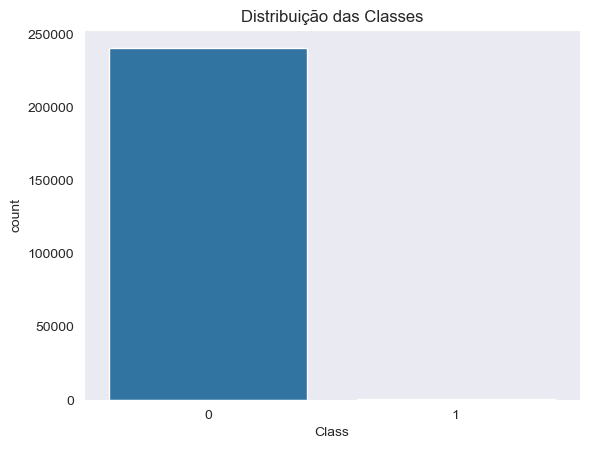

In [11]:
# verifica o balanceamento das classes
print(df1.Class.value_counts())
print("\nFraudes representam {:.2f}% do dataset.\n".format((df1[df1.Class == 1].shape[0] / df1.shape[0]) * 100))

# plota um gráfico de barras para as Classes
fig, ax = plt.subplots()
sns.countplot(x='Class', data=df1, ax=ax)
ax.set_title('Distribuição das Classes')
plt.show()

Conforme informado na descrição dos dados, as entradas relativas às transações fraudulentas correspondem a 0,17% do total.

O gráfico de barras mostra como essa discrepância se torna nítida e visível. Na prática, isso interfere no desempenho do modelo, e será necessário fazer um balanceamento dos dados antes de alimentar o modelo final de classificação.

### Variável `Time`

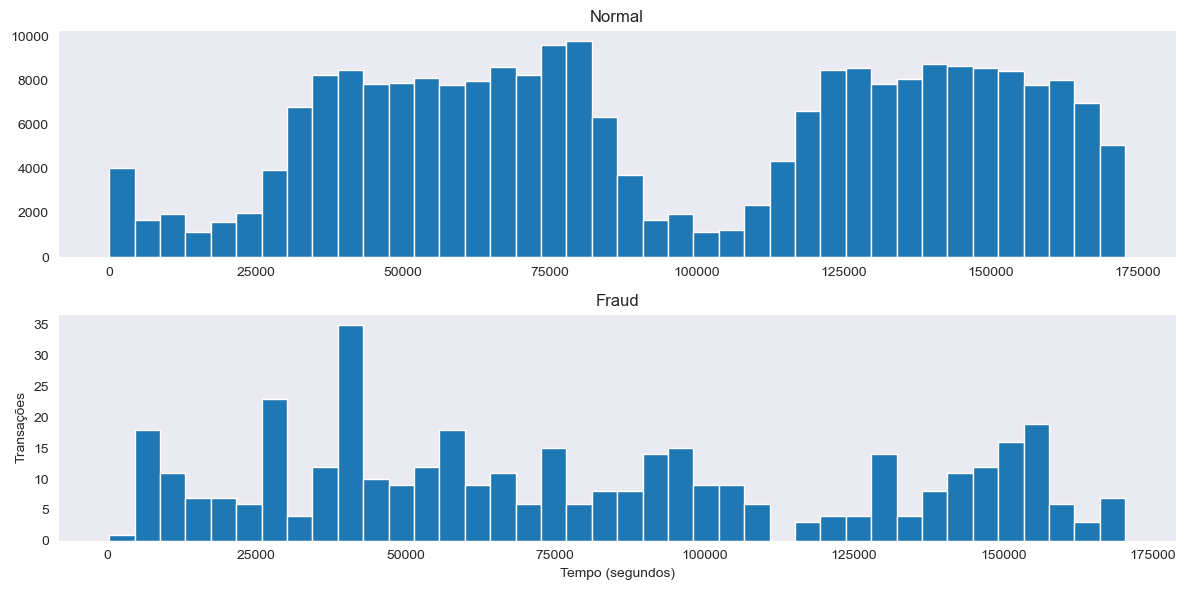

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12,6))

num_bins = 40

ax[0].hist(df1.Time[df1.Class == 0], bins=num_bins)
ax[0].set_title('Normal')

ax[1].hist(df1.Time[df1.Class == 1], bins=num_bins)
ax[1].set_title('Fraud')

plt.xlabel('Tempo (segundos)')
plt.ylabel('Transações')
plt.tight_layout()

Histogramas a fim de comparar as distribuições das 2 classes ao longo da dimensão tempo (`Time`). Não foi identificada nenhuma informação a partir das distribuições de frequência.

### Variável `Amount`

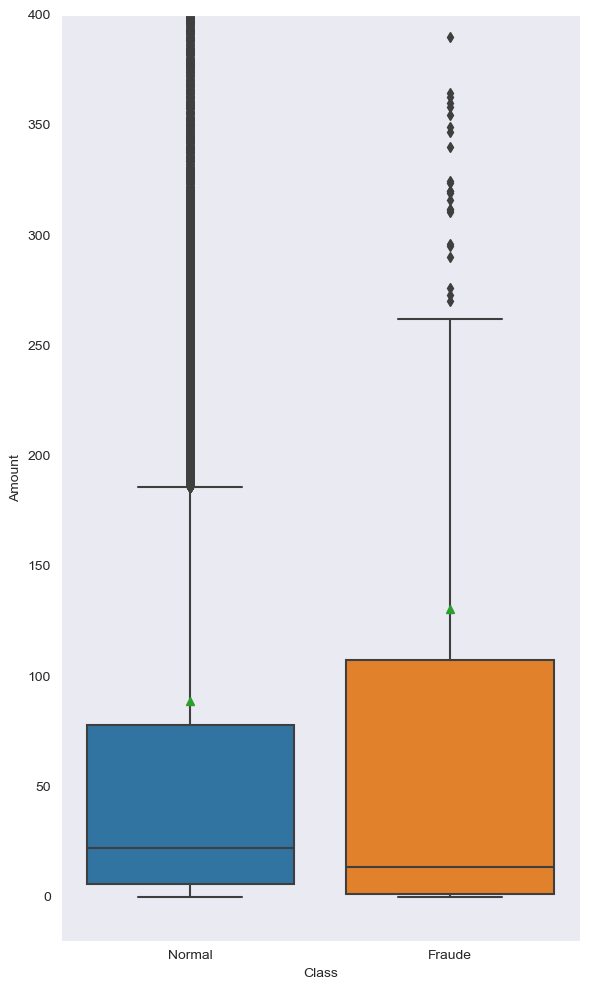

In [13]:
fig, ax = plt.subplots(figsize=(6,10), sharex=True)

sns.boxplot(x='Class', y='Amount', data=df1, showmeans=True)
plt.ylim((-20, 400))
plt.xticks([0, 1], ['Normal', 'Fraude'])

plt.tight_layout()

In [14]:
amount_normal_describe = pd.Series(df1[df1.Class == 0]['Amount'].describe(), name='Normal')
amount_fraud_describe  = pd.Series(df1[df1.Class == 1]['Amount'].describe(), name='Fraud')

df1_amount_describe = pd.concat([amount_normal_describe, amount_fraud_describe], axis=1)
df1_amount_describe

,Normal,Fraud
count,240885.000000,400.000000
mean,88.653934,130.632625
std,247.843968,271.867178
min,0.000000,0.000000
25%,5.720000,1.000000
50%,22.000000,13.385000
75%,77.730000,107.302500
max,19656.530000,2125.870000


De uma maneira geral, percebe-se uma distribuição diferente para as duas classes, o que provavelmente irá contribuir para o treinamento do modelo de *machine learning*.

### Variáveis `V1, V2, V3...V28`

O gráfico de densidade é muito útil para compararmos as distribuições de cada variável para cada classe e ver quais as mais importantes para detecção de anomalias.

O que se procura nesse tipo de visualização são distribuições que diferem uma da outra, permitindo identificar fraudes mais facilmente. Veja como exemplo as variáveis `V3`, `V4`, `V10` e `V11`, como elas são bem distintas.

Por outro lado, variáveis como `V8`, `V13` e `V15` são muito similares, apresentando aproximadamente o mesmo comportamento.

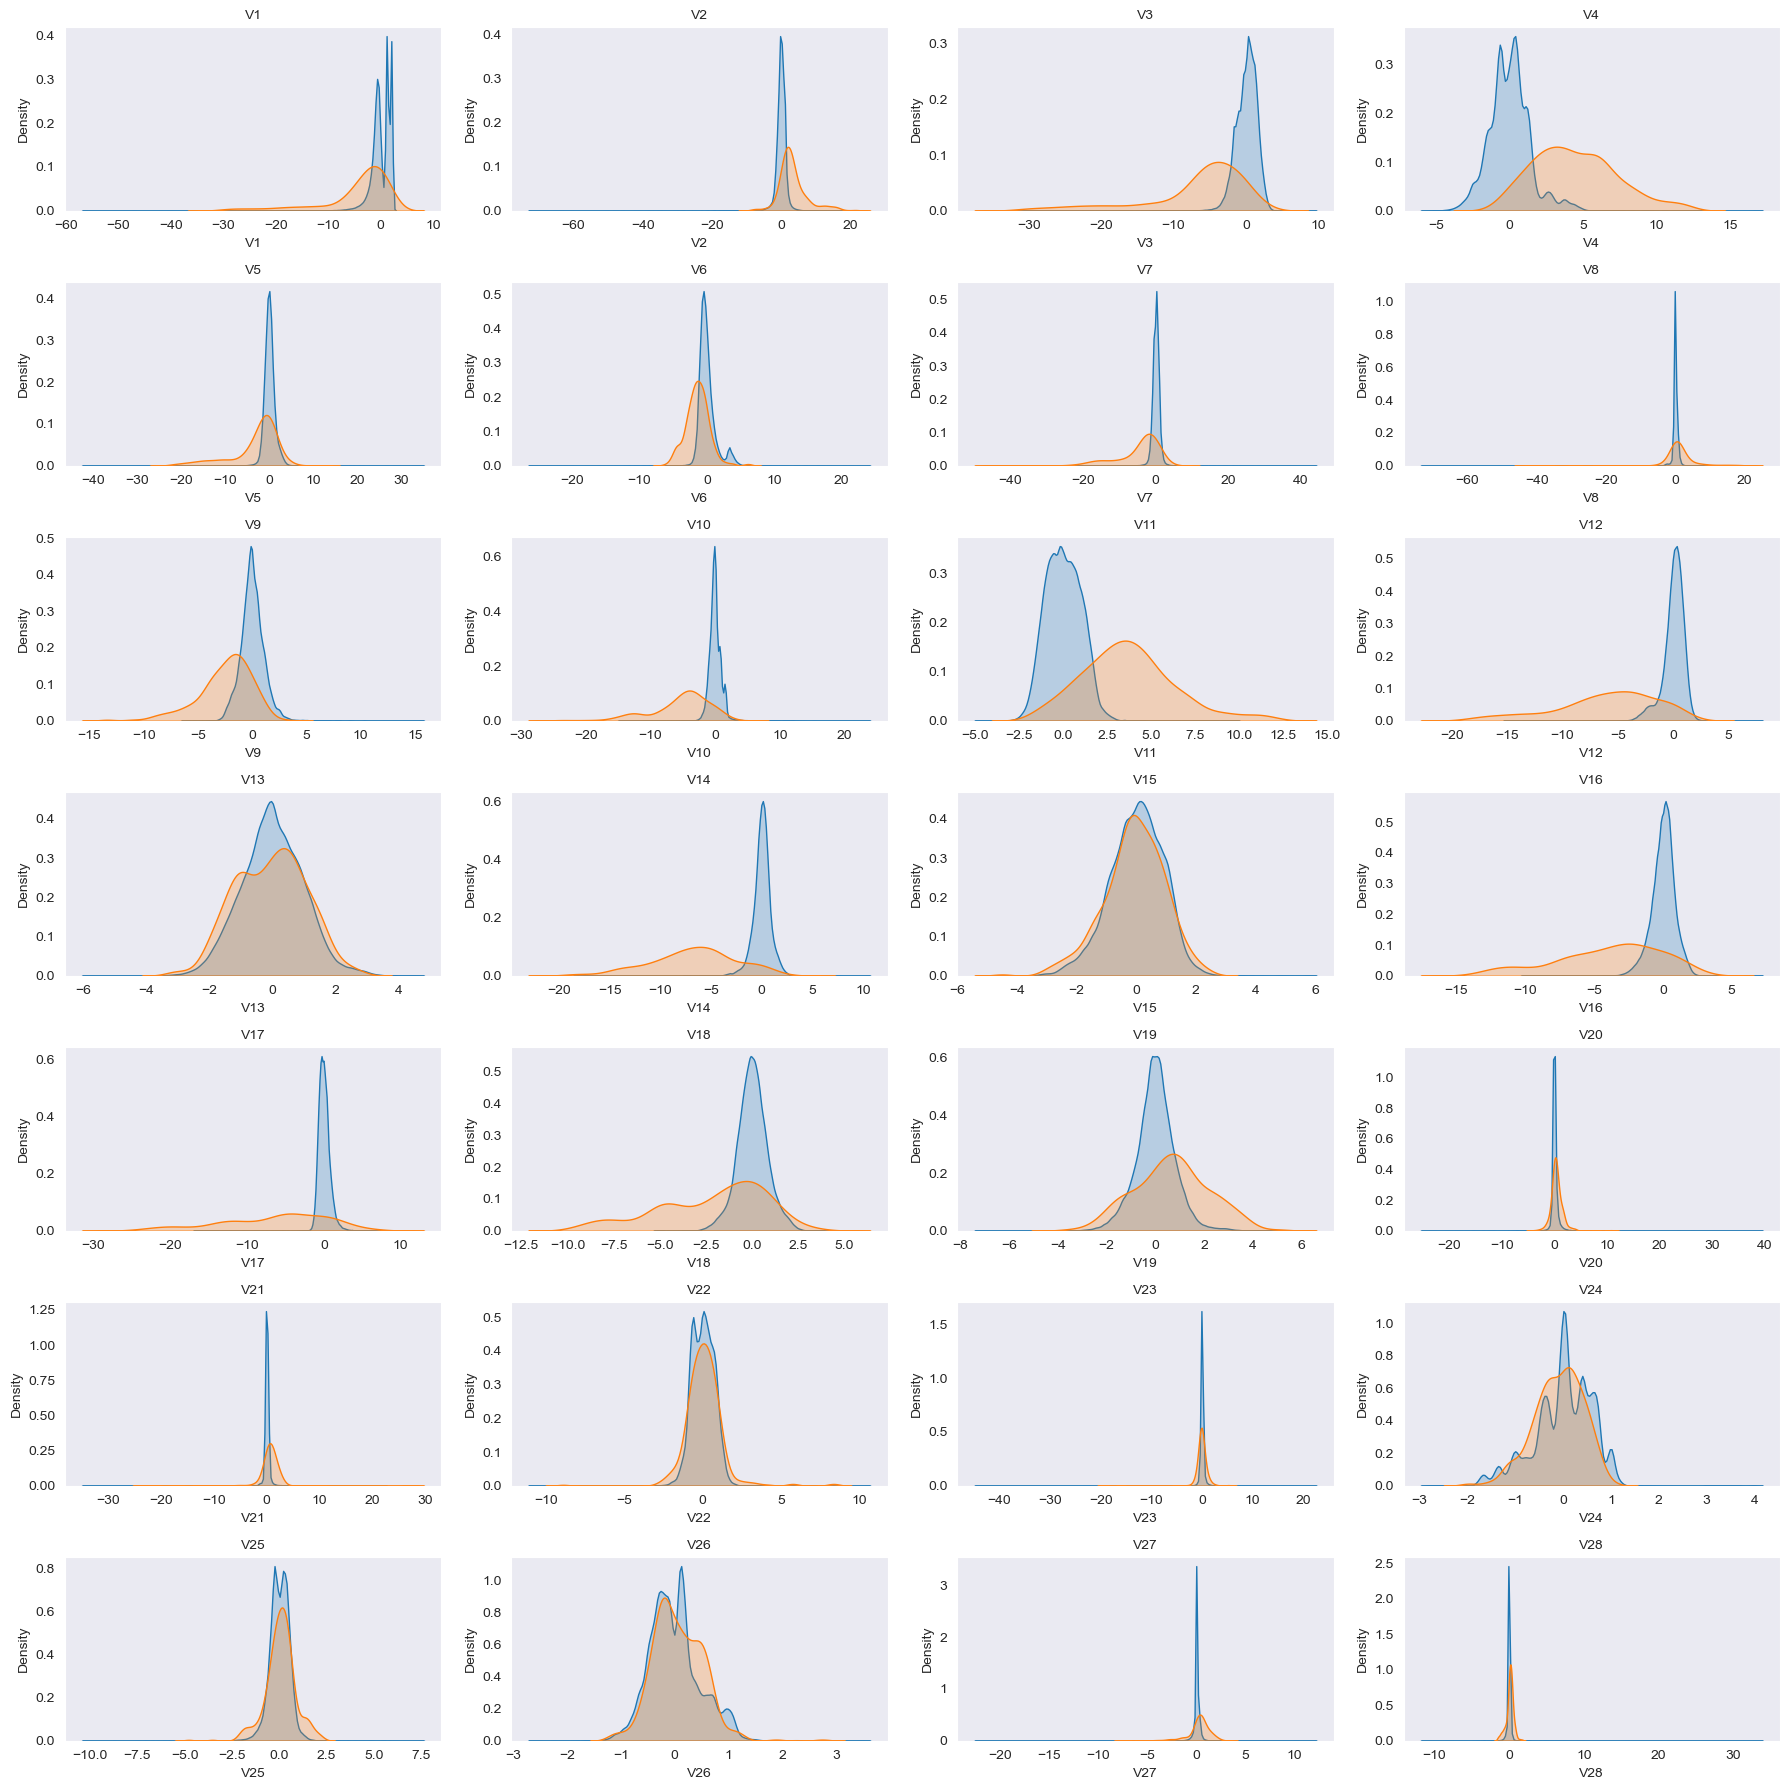

In [15]:
column_names = df1.drop(['Class', 'Amount', 'Time'], axis=1).columns
num_plots = len(column_names)
df1_class_0 = df1[df1.Class == 0]
df1_class_1 = df1[df1.Class == 1]

fig, ax = plt.subplots(nrows=7, ncols=4, figsize=(18,18))
fig.subplots_adjust(hspace=1, wspace=1)

idx = 0
for col in column_names:
    idx += 1
    plt.subplot(7, 4, idx)
    sns.kdeplot(df1_class_0[col], label="Class 0", shade=True)
    sns.kdeplot(df1_class_1[col], label="Class 1", shade=True)
    plt.title(col, fontsize=10)
    
plt.tight_layout()

Resumidamente, algumas observações principais que puderam ser extraídas dessa etapa exploratória foram:

* O *dataset* está muito desbalanceado, uma vez que as transações fraudulentas representam apenas 0,17% das entradas totais.
* Não existem valores ausentes ou nulos no *dataframe*.
* Uma vez que a PCA é sensível à escala das variáveis, assume-se a premissa que as *features* originais foram padronizadas.
* As colunas `Time` e `Amount` não estão normalizadas.

## Pré-processamento

Etapas da preparação dos dados para os modelos de Machine Learning:

* Padronizar as *features* `Time` e `Amount`, que estão em outra ordem de grandeza.
* Dividir entre dados de treino e validação
* Balancear os dados a fim de evitar uma baixa performance para a classe 1 e *overfitting*.

### Padronização `Time` e `Amount`

Para esta etapa, uma vez que a coluna `Amount` possui *outliers* será usada a padronização por meio da classe `StandardScaler`.

In [16]:
# padroniza as colunas Time e Amount
df1_clean = df1.copy()

std_scaler = StandardScaler()
df1_clean['std_amount'] = std_scaler.fit_transform(df1_clean['Amount'].values.reshape(-1, 1))
df1_clean['std_time'] = std_scaler.fit_transform(df1_clean['Time'].values.reshape(-1, 1))

df1_clean.drop(['Time', 'Amount'], axis=1, inplace=True)

# verifica as primeiras entradas
df1_clean.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,std_amount,std_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.245659,-1.997564
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.347063,-1.997564
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.169615,-1.997543
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140290,-1.997543
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.075572,-1.997522


### Divisão entre conjuntos de Treino e Validação

Antes de proceder com o balanceamento de dados, devemos splitar os dados já existentes entre Treino e Validação. Caso contrário, não teremos parâmetros para conferir se o balanceamento foi adequado.

Para garantir que os conjuntos de Treino e Validação tenham a mesma quantidade de classes proporcionalmente, passamos `stratify=True`.

In [17]:
# separa variáveis entre X e y
X = df1_clean.drop('Class', axis=1)
y = df1['Class']

# divide o dataset entre treino e teste
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, shuffle=True, random_state=42)

### Balanceamento dos dados

Usando a biblioteca `imblearn` é possível aplicar facilmente técnicas de balanceamento de dados.

#### Validação Cruzada (Stratified K-Fold CV) - no sampling

In [21]:
kf = StratifiedKFold(n_splits=3, shuffle=False)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

score = cross_val_score(rf, X_train, y_train, cv=kf, scoring='roc_auc')

print(f'Validação Cruzada: {score}')
print(f'Média da Validação Cruzada: {score.mean()}')

Validação Cruzada: [0.96356611 0.92843975 0.95834352]
Média da Validação Cruzada: 0.9501164599281534


**Otimização de Hyperparametro com GridSearchCV**

In [47]:
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 10, 12],
}

grid_rf = GridSearchCV(rf, param_grid=params, cv=kf, scoring='roc_auc').fit(X_train, y_train)

print('Melhores parametros: ', grid_rf.best_params_)
print('Melhor score: ', grid_rf.best_score_)

Melhores parametros:  {'max_depth': 12, 'n_estimators': 100}
Melhor score:  0.9715213408390206


**Métricas de avaliação**

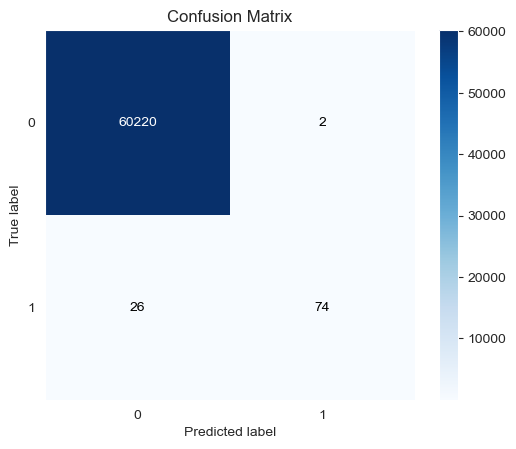

In [52]:
rf_tunned = RandomForestClassifier(max_depth=12, n_estimators=100, random_state=42, n_jobs=-1)
rf_tunned.fit(X_train, y_train)
y_pred = rf_tunned.predict(X_val)

rf_Recall = recall_score(y_val, y_pred)
rf_Precision = precision_score(y_val, y_pred)
rf_f1 = f1_score(y_val, y_pred)
rf_roc_auc = roc_auc_score(y_val, y_pred)

skplt.metrics.plot_confusion_matrix(y_val, y_pred, normalize=False);

In [53]:
ndf = [(rf_Recall, rf_Precision, rf_f1, rf_roc_auc)]

rf_score = pd.DataFrame(data=ndf, columns=['Recall', 'Precision', 'F1 Score', 'AUC ROC'])
rf_score.insert(0, 'Random Forest with', 'No Under/Oversampling')
rf_score

,Random Forest with,Recall,Precision,F1 Score,AUC ROC
0,No Under/Oversampling,0.74,0.973684,0.840909,0.869983


#### Validação Cruzada (Random Oversampling)

In [54]:
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train, y_train)

print('Normal:', y_over.value_counts()[0], '/', round(y_over.value_counts()[0] / len(y_over) * 100, 2),'% do dataset')
print('Fraude:', y_over.value_counts()[1], '/', round(y_over.value_counts()[1] / len(y_over) * 100, 2),'% do dataset')

Normal: 180663 / 50.0 % do dataset
Fraude: 180663 / 50.0 % do dataset


**Treinando o modelo**

In [55]:
# pipeline para random oversampling
random_overs_pipeline = make_pipeline(RandomOverSampler(random_state=42),
                                      RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))

score_over = cross_val_score(random_overs_pipeline, X_train, y_train, scoring='roc_auc', cv=kf)

print(f'Validação Cruzada: {score_over}')
print(f'Média da Validação Cruzada: {score_over.mean()}')

Validação Cruzada: [0.95806048 0.92819216 0.95283306]
Média da Validação Cruzada: 0.9463619003337707


**GridSearchCV**

In [56]:
new_params = {'randomforestclassifier__' + key: params[key] for key in params}
grid_over_rf = GridSearchCV(random_overs_pipeline, param_grid=new_params, cv=kf, scoring='roc_auc', return_train_score=True)
grid_over_rf.fit(X_train, y_train)

print('Melhores parametros: ', grid_over_rf.best_params_)
print('Melhor score: ', grid_over_rf.best_score_)

Melhores parametros:  {'randomforestclassifier__max_depth': 4, 'randomforestclassifier__n_estimators': 50}
Melhor score:  0.9746493748028097


**Métricas de avaliação**

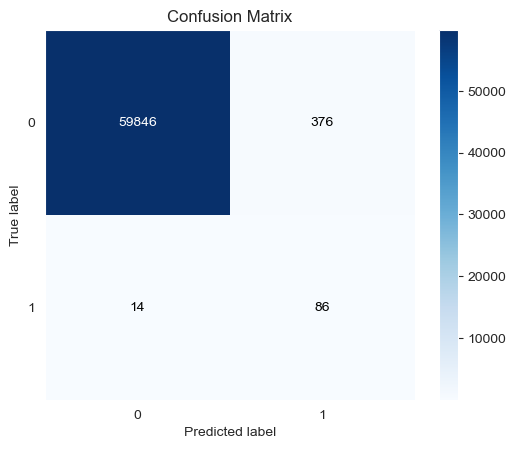

In [60]:
y_pred = grid_over_rf.best_estimator_.named_steps['randomforestclassifier'].predict(X_val)

over_rf_Recall = recall_score(y_val, y_pred)
over_rf_Precision = precision_score(y_val, y_pred)
over_rf_f1 = f1_score(y_val, y_pred)
over_rf_roc_auc = roc_auc_score(y_val, y_pred)

skplt.metrics.plot_confusion_matrix(y_val, y_pred, normalize=False);

In [61]:
ndf = [(over_rf_Recall, over_rf_Precision, over_rf_f1, over_rf_roc_auc)]

over_rf_score = pd.DataFrame(data=ndf, columns=['Recall', 'Precision', 'F1 Score', 'AUC ROC'])
over_rf_score.insert(0, 'Random Forest with', 'Random Oversampling')
over_rf_score

,Random Forest with,Recall,Precision,F1 Score,AUC ROC
0,Random Oversampling,0.86,0.186147,0.30605,0.926878


#### Validação Cruzada (Random Undersampling)

In [62]:
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print('Normal:', y_under.value_counts()[0], '/', round(y_under.value_counts()[0] / len(y_under) * 100, 2),'% do dataset')
print('Fraude:', y_under.value_counts()[1], '/', round(y_under.value_counts()[1] / len(y_under) * 100, 2),'% do dataset')

Normal: 300 / 50.0 % do dataset
Fraude: 300 / 50.0 % do dataset


Nosso conjunto de dados após o undersampling apresenta apenas 600 registros, portanto não é a melhor ideia aproveitar essa técnica.

#### Validação Cruzada (SMOTE)

In [63]:
# pipeline para random oversampling
smote_pipeline = make_pipeline(SMOTE(random_state=42),
                               RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))

score_smote = cross_val_score(smote_pipeline, X_train, y_train, scoring='roc_auc', cv=kf)

print(f'Validação Cruzada: {score_smote}')
print(f'Média da Validação Cruzada: {score_smote.mean()}')

Validação Cruzada: [0.97412074 0.93231149 0.96312532]
Média da Validação Cruzada: 0.9565191821236225


**GridSearchCV**

In [64]:
new_params = {'randomforestclassifier__' + key: params[key] for key in params}
smote_rf = GridSearchCV(smote_pipeline, param_grid=new_params, cv=kf, scoring='roc_auc', return_train_score=True)
smote_rf.fit(X_train, y_train)

print('Melhores parametros: ', smote_rf.best_params_)
print('Melhor score: ', smote_rf.best_score_)

Melhores parametros:  {'randomforestclassifier__max_depth': 4, 'randomforestclassifier__n_estimators': 100}
Melhor score:  0.9752545346861283


**Métricas de avaliação**

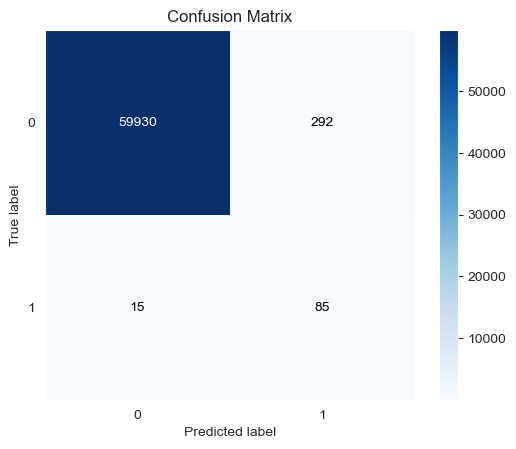

In [66]:
y_pred = smote_rf.best_estimator_.named_steps['randomforestclassifier'].predict(X_val)

smote_rf_Recall = recall_score(y_val, y_pred)
smote_rf_Precision = precision_score(y_val, y_pred)
smote_rf_f1 = f1_score(y_val, y_pred)
smote_rf_roc_auc = roc_auc_score(y_val, y_pred)

skplt.metrics.plot_confusion_matrix(y_val, y_pred, normalize=False);

In [67]:
ndf = [(smote_rf_Recall, smote_rf_Precision, smote_rf_f1, smote_rf_roc_auc)]

smote_rf_score = pd.DataFrame(data=ndf, columns=['Recall', 'Precision', 'F1 Score', 'AUC ROC'])
smote_rf_score.insert(0, 'Random Forest with', 'SMOTE')
smote_rf_score

,Random Forest with,Recall,Precision,F1 Score,AUC ROC
0,SMOTE,0.85,0.225464,0.356394,0.922576


#### Validação Cruzada Combinando a técnica SMOTE e Tomek Links

Uma combinação de oversampling da classe minoritária e undersampling da classe majoritária pode alcançar melhor desempenho do classificador do que apenas undersampling da classe majoritária. Este método foi introduzido pela primeira vez por Batista et al. (2003), como indica o kernel: https://www.kaggle.com/code/marcinrutecki/best-techniques-and-metrics-for-imbalanced-dataset

**Treinando o Modelo**

In [69]:
SMOTETomek_pipeline = make_pipeline(SMOTETomek(tomek=TomekLinks(sampling_strategy='majority')),
                                    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))

score_smote_tomek = cross_val_score(SMOTETomek_pipeline, X_train, y_train, scoring='roc_auc', cv=kf)

print(f'Validação Cruzada: {score_smote_tomek}')
print(f'Média da Validação Cruzada: {score_smote_tomek.mean()}')

Validação Cruzada: [0.97272596 0.94192973 0.96392222]
Média da Validação Cruzada: 0.9595259682392078


**GridSearchCV**

GridSearchCV combinado com SMOTE-Tomek e k-fold Cross-Validation é computacionalmente muito exigente.

**Métricas de avaliação**

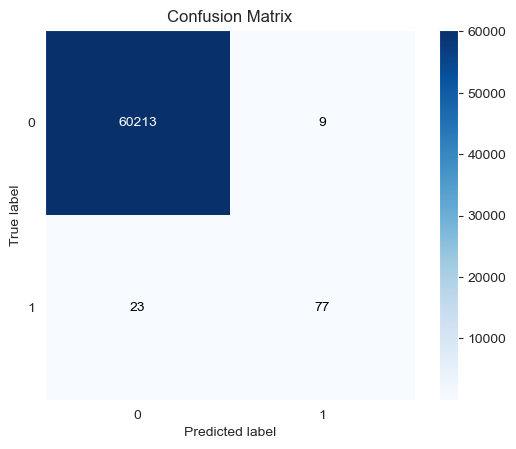

In [70]:
SMOTETomek_rf = SMOTETomek_pipeline
SMOTETomek_rf.fit(X_train, y_train)
y_pred = SMOTETomek_rf.predict(X_val)

smote_tomek_rf_Recall = recall_score(y_val, y_pred)
smote_tomek_rf_Precision = precision_score(y_val, y_pred)
smote_tomek_rf_f1 = f1_score(y_val, y_pred)
smote_tomek_rf_roc_auc = roc_auc_score(y_val, y_pred)

skplt.metrics.plot_confusion_matrix(y_val, y_pred, normalize=False);

In [71]:
ndf = [(smote_tomek_rf_Recall, smote_tomek_rf_Precision, smote_tomek_rf_f1, smote_tomek_rf_roc_auc)]

smote_tomek_rf_score = pd.DataFrame(data=ndf, columns=['Recall', 'Precision', 'F1 Score', 'AUC ROC'])
smote_tomek_rf_score.insert(0, 'Random Forest with', 'SMOTE + Tomek')
smote_tomek_rf_score

,Random Forest with,Recall,Precision,F1 Score,AUC ROC
0,SMOTE + Tomek,0.77,0.895349,0.827957,0.884925


#### Validação Cruzada (Random Forest - Class weights)

In [72]:
# Se você escolhe class_weight = "balanceado", as classes serão ponderadas inversamente proporcionais à frequência com que aparecem nos dados.
rfb = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")
balanced_rf = cross_val_score(rfb, X_train, y_train, cv=kf, scoring='roc_auc')

print(f'Validação Cruzada: {balanced_rf}')
print(f'Média da Validação Cruzada: {balanced_rf.mean()}')

Validação Cruzada: [0.95867397 0.93355931 0.94342439]
Média da Validação Cruzada: 0.9452192203162796


**GridSearchCV**

In [73]:
grid_rfb = GridSearchCV(rfb, param_grid=params, cv=kf, scoring='roc_auc').fit(X_train, y_train)

print('Melhores parametros: ', grid_rfb.best_params_)
print('Melhor score: ', grid_rfb.best_score_)

Melhores parametros:  {'max_depth': 4, 'n_estimators': 50}
Melhor score:  0.9749118801304086


**Métricas de avaliação**

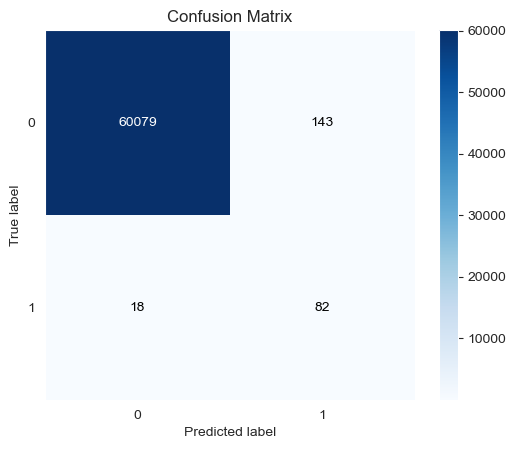

In [78]:
y_pred = grid_rfb.best_estimator_.predict(X_val)

grid_rfb_Recall = recall_score(y_val, y_pred)
grid_rfb_Precision = precision_score(y_val, y_pred)
grid_rfb_f1 = f1_score(y_val, y_pred)
grid_rfb_roc_auc = roc_auc_score(y_val, y_pred)

skplt.metrics.plot_confusion_matrix(y_val, y_pred, normalize=False);

In [80]:
ndf = [(grid_rfb_Recall, grid_rfb_Precision, grid_rfb_f1, grid_rfb_roc_auc)]

grid_rfb_score = pd.DataFrame(data=ndf, columns=['Recall', 'Precision', 'F1 Score', 'AUC ROC'])
grid_rfb_score.insert(0, 'Random Forest with', 'Class weights')
grid_rfb_score

,Random Forest with,Recall,Precision,F1 Score,AUC ROC
0,Class weights,0.82,0.364444,0.504615,0.908813


#### Comparando as desempenhos

In [81]:
predictions = pd.concat([rf_score, over_rf_score, smote_rf_score, smote_tomek_rf_score, grid_rfb_score], ignore_index=True, sort=False)
predictions.sort_values(by=['AUC ROC'], ascending=False)

,Random Forest with,Recall,Precision,F1 Score,AUC ROC
1,Random Oversampling,0.86,0.186147,0.306050,0.926878
2,SMOTE,0.85,0.225464,0.356394,0.922576
4,Class weights,0.82,0.364444,0.504615,0.908813
3,SMOTE + Tomek,0.77,0.895349,0.827957,0.884925
0,No Under/Oversampling,0.74,0.973684,0.840909,0.869983


Através dos testes conclui que utilizar a técnica *Random Over-sampling* obteve o melhor resultado.

#### Comparação entre os dados balanceados e não balanceados

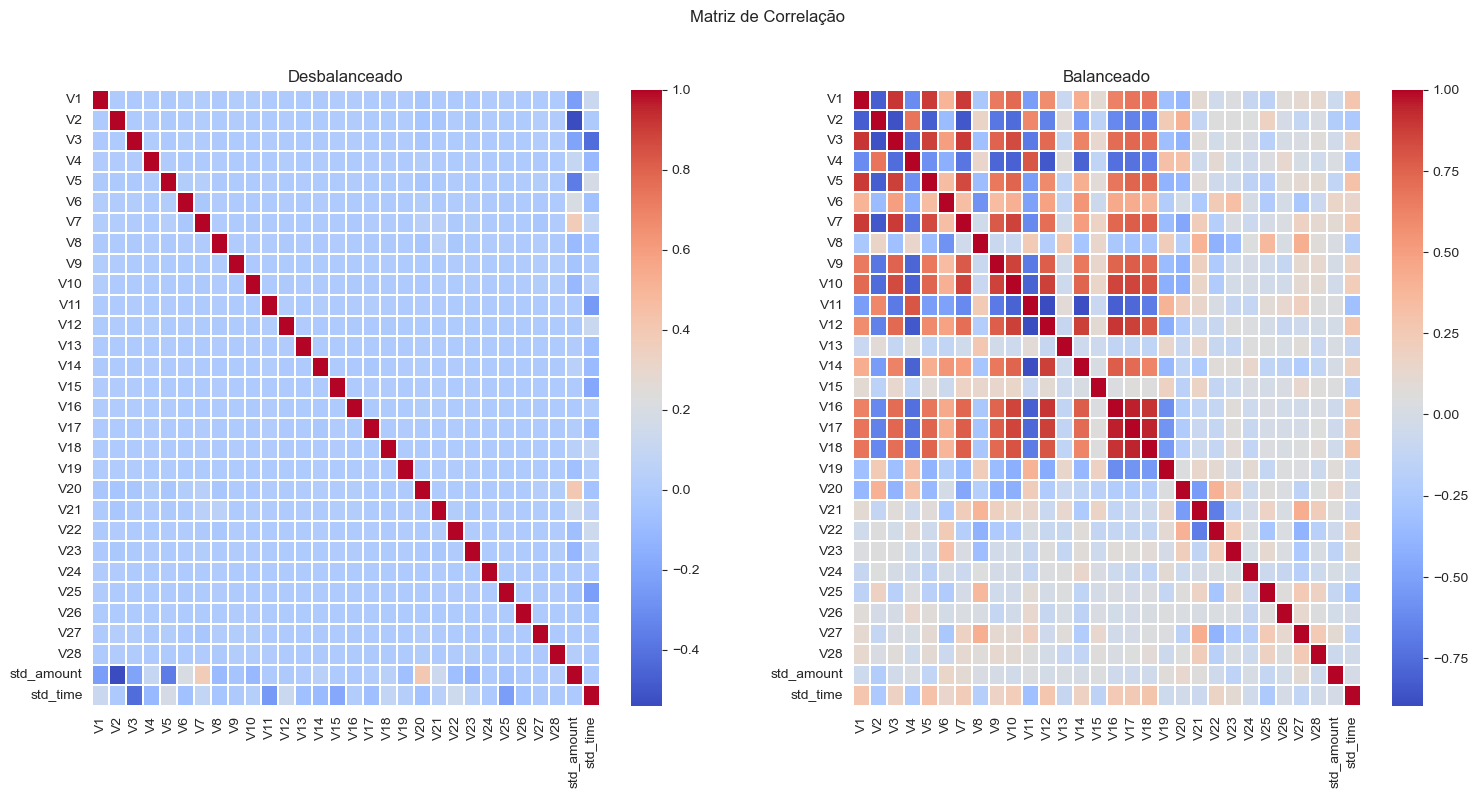

In [82]:
# matriz de correlação
corr = X_train.corr()
corr_over = pd.DataFrame(X_over).corr()


fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (18,8))
fig.suptitle('Matriz de Correlação')

sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns,
            linewidths=.1, cmap="coolwarm", ax=ax[0])
ax[0].set_title('Desbalanceado')

sns.heatmap(corr_over, xticklabels=corr.columns, yticklabels=corr.columns,
            linewidths=.1, cmap="coolwarm", ax=ax[1])
ax[1].set_title('Balanceado')

plt.show()

Observe como sem o balanceamento a matriz de correlação não trazia nenhuma informação relevante. Após um correto balanceamento podemos identificar quais variáveis estão fortemente relacionadas.

## Modelo Final

Com todos os dados preparados e após um teste extensivo para entender qual tipo de balanceamento o modelo melhor se adaptava, chegamos a uma conclusão final. 

Treinaremos nosso modelo de RandomForest com os parametros já treinados anteriormente atráves do *GridSearchCV* juntamente com a técnica de balanceamento que apresentou o melhor desempenho *(Random Over-samplimg)*.

In [83]:
grid_over_rf.best_estimator_

Pipeline(steps=[('randomoversampler', RandomOverSampler(random_state=42)),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=4, n_estimators=50, n_jobs=-1,
                                        random_state=42))])

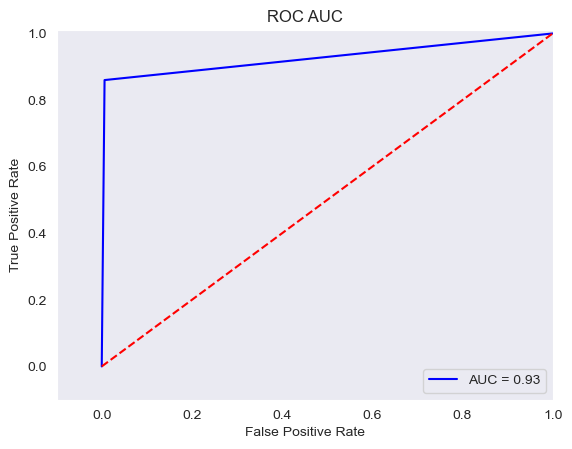

In [84]:
# modelo já treinado e com a técnica over-sampling
np.random.seed(2)
y_pred = grid_over_rf.best_estimator_.predict(X_val)

# previsões em cima dos dados de validação
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.title('ROC AUC')
plt.plot(fpr, tpr, 'b',label='AUC = %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.0])
plt.ylim([-0.1,1.01])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## Fazendo Previsões no Conjunto de Teste

No começo do projeto, realizamos um split nos dados para que tivéssemos 3 conjuntos: Um de treino, um de validação e um de teste.

Agora que já exploramos e preparamos os dados, instaciamos o modelo e fizemos previsões no conjunto de validação, é hora de descobrirmos o potencial desse modelo com os dados de teste.

O que faremos é apenas utilizar o modelo que treinamos com um novo conjunto. Mas, para que os resultados sejam justos, precisamos fazer com que os novos dados estejam nas mesmas condições daqueles que o nosso modelo espera.

Nesse caso, precisamos padronizar as colunas Time e Amount. Não podemos balancear os dados pois haveria perda. Nosso modelo precisa ser tratado mas precisamos fazer previsões em todas as linhas que ele receber.


In [85]:
# padroniza as colunas Time e Amount - Teste
test_clean = test.copy()

std_scaler = StandardScaler()
test_clean['std_amount'] = std_scaler.fit_transform(test_clean['Amount'].values.reshape(-1, 1))
test_clean['std_time'] = std_scaler.fit_transform(test_clean['Time'].values.reshape(-1, 1))

test_clean.drop(['Time', 'Amount'], axis=1, inplace=True)

# verifica as primeiras entradas
test_clean.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,std_amount,std_time
183484,-0.323334,1.057455,-0.048341,-0.607204,1.259821,-0.091761,1.159101,-0.124335,-0.174640,-1.644401,...,-0.433890,-0.261613,-0.046651,0.211512,0.008297,0.108494,0.161139,0,-0.177738,0.658372
255448,-0.349718,0.932619,0.142992,-0.657071,1.169784,-0.733369,1.009985,-0.071069,-0.302083,-1.192404,...,-0.833209,-0.030360,0.490035,-0.404816,0.134350,0.076830,0.175562,0,-0.321945,1.320094
244749,-1.614711,-2.406570,0.326194,0.665520,2.369268,-1.775367,-1.139049,0.329904,0.903813,-0.219013,...,1.134489,0.965054,0.640981,-1.801998,-1.041114,0.286285,0.437322,0,0.034666,1.219742
63919,-2.477184,0.860613,1.441850,1.051019,-1.856621,2.078384,0.510828,-0.243399,-0.260691,0.133040,...,0.692245,0.150121,-0.260777,0.005183,-0.177847,-0.510060,-0.660533,0,0.838765,-0.919236
11475,1.338831,-0.547264,0.737389,-0.212383,-1.110039,-0.525744,-0.801403,-0.063672,0.997276,0.113386,...,-0.074719,0.067055,0.333122,0.379087,-0.268706,-0.002769,0.003272,0,-0.310490,-1.572827


Agora basta separar entre X e Y, e fazer nossas previsões.

In [87]:
# separa variáveis entre X e y
X_test = test_clean.drop('Class', axis=1)
y_test = test['Class']

# fazer as previsões em cima dos dados de teste
y_pred = grid_over_rf.best_estimator_.predict(X_test)
y_proba = grid_over_rf.best_estimator_.predict_proba(X_test)

Pronto! Com nossas previsões feitas, é hora de visualizar os resultados.

AUC: 0.9296


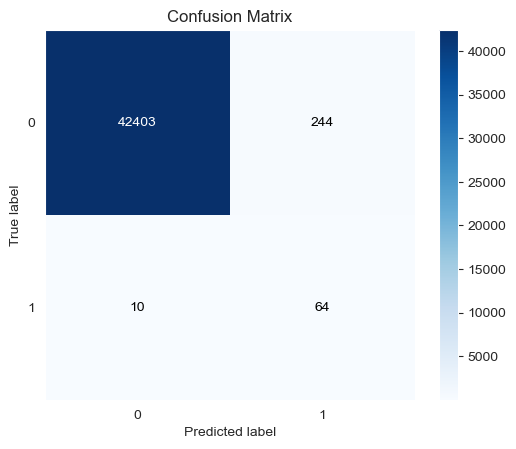

In [89]:
# imprimir a área sob da curva
print(f"AUC: {roc_auc_score(y_test, y_pred):.4f}")

# plotar a matrix de confusão
skplt.metrics.plot_confusion_matrix(y_test, y_pred, normalize=False);

Podemos ver que nossos resultados foram ainda melhores do que no conjunto de validação, o que é um excelente resultado!

Conjunto de Validação - Os nossos False Negatives = 14<br>
Conjunto de Teste     - Os nossos False Negatives = 10

## Melhorias

- Poderiamos treinar com outros tipos de modelos de Machine Learning
- Poderiamos realizar uma técnica de Feature Selection para tentar aprimorar os resultados


## Referencias

https://www.kaggle.com/code/marcinrutecki/best-techniques-and-metrics-for-imbalanced-dataset#8.-Random-Resampling-Imbalanced-Datasets

https://cursos.sigmoidal.ai/

https://scikit-learn.org/stable/index.html

https://imbalanced-learn.org/stable/user_guide.html